<a href="https://colab.research.google.com/github/elariekerboull/master_uppsala/blob/main/Machine%20Learning/Exercise_6_3_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 6.3: Neural Networks in Keras - Solution

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# See https://keras.io/
# for extennsive documentation
import tensorflow as tf
from tensorflow import keras

from keras.models import Sequential
from keras.layers import Dense

Let us visit the problem of wine quality prediction previously encountered one final time. After linear regression and a self-made network, we can now explore the comfort provided by the Keras library.

In [ ]:
# The code snippet below is responsible for downloading the dataset to
# Google. You can directly download the file using the link
# if you work with a local anaconda setup
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv

--2023-11-10 10:35:15--  https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘winequality-white.csv’

winequality-white.c     [ <=>                ] 258.23K  --.-KB/s    in 0.08s   

2023-11-10 10:35:16 (3.25 MB/s) - ‘winequality-white.csv’ saved [264426]



In [ ]:
# load all examples from the file
data = np.genfromtxt('winequality-white.csv',delimiter=";",skip_header=1)

print("data:", data.shape)

# Prepare for proper training
np.random.seed(1234) # set seed to get reproducable results
np.random.shuffle(data) # randomly sort examples

# the performance can be increased by normalizing the data per feature
# (this is a crucial step if SDG or SDG with momentum is used)
mean = np.mean(data, axis=0)
std = np.std(data, axis = 0)
print(mean.shape)

data = (data - mean)/std

# take the first 3000 examples for training
X_train = data[:3000,:11] # all features except last column
y_train = data[:3000,11]  # quality column

# and the remaining examples for testing
X_test = data[3000:,:11] # all features except last column
y_test = data[3000:,11] # quality column

print("First example:")
print("Features:", X_train[0])
print("Quality:", y_train[0])


data: (4898, 12)
(12,)
First example:
Features: [-0.89452915 -0.57787912  1.28759423 -0.96448315  0.23929812 -1.01779928
 -1.20866448 -0.41041123  0.74002864 -0.26155273 -0.74300757]
Quality: -0.9913739176034732


Below is the simple network from exercise 4.1 implemented using Keras. In addition to the network we define the loss function and optimiser.

In [ ]:
# See: https://keras.io/api/models/sequential/ and
# https://keras.io/api/layers/core_layers/dense/
# We can use the Sequential class to very easiliy
# build a simple architecture
model = Sequential()
# 11 inputs, 20 outputs, relu
model.add(Dense(20, input_dim=11, activation='relu'))
model.add(Dense(20, activation='relu'))
model.add(Dense(20, activation='relu'))
# 20 inputs (automatically detected by Keras), 1 output, linear activation
model.add(Dense(1, activation='linear'))

print(model.summary())
# Set loss function and optimiser algorithm
# Remove comments from of these versions:

# Initial:
# model.compile(loss='mse',  # mean squared error
#              optimizer='sgd'# stochastic gradient descent
#             )
#
# sgd with mometum
# instead of passing a string, we can explicitely construct the optimizer object
# this gives us more control over its properties
# opt = keras.optimizers.SGD(momentum=0.8, learning_rate=0.001)
# model.compile(loss='mse',  # mean squared error
#              optimizer=opt
#             )
#
# Adam:
opt = keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='mse',  # mean squared error
              optimizer=opt
             )




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 20)                240       
                                                                 
 dense_1 (Dense)             (None, 20)                420       
                                                                 
 dense_2 (Dense)             (None, 20)                420       
                                                                 
 dense_3 (Dense)             (None, 1)                 21        
                                                                 
Total params: 1101 (4.30 KB)
Trainable params: 1101 (4.30 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


# Training and evaluation below

The code below trains the network for 5 epochs using the loss function and optimiser defined above. Each example is individually passed to the network

In [ ]:
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    # validation_split=0.2,
                    epochs=70, batch_size=32) # changed batch size to 10


Epoch 1/70
94/94 [==============================] - 3s 10ms/step - loss: 0.8750 - val_loss: 0.7757
Epoch 2/70
94/94 [==============================] - 1s 5ms/step - loss: 0.7355 - val_loss: 0.7097
Epoch 3/70
94/94 [==============================] - 1s 6ms/step - loss: 0.6831 - val_loss: 0.6781
Epoch 4/70
94/94 [==============================] - 1s 6ms/step - loss: 0.6579 - val_loss: 0.6667
Epoch 5/70
94/94 [==============================] - 1s 8ms/step - loss: 0.6415 - val_loss: 0.6579
Epoch 6/70
94/94 [==============================] - 1s 8ms/step - loss: 0.6289 - val_loss: 0.6525
Epoch 7/70
94/94 [==============================] - 1s 6ms/step - loss: 0.6191 - val_loss: 0.6451
Epoch 8/70
94/94 [==============================] - 1s 8ms/step - loss: 0.6073 - val_loss: 0.6410
Epoch 9/70
94/94 [==============================] - 1s 6ms/step - loss: 0.6028 - val_loss: 0.6372
Epoch 10/70
94/94 [==============================] - 1s 7ms/step - loss: 0.5947 - val_loss: 0.6329
Epoch 11/70
94/94 

In [ ]:
# The history object returned by the model training above
# contains the values of the loss function (the mean-squared-error)
# at different epochs
# We discard the first epoch as the loss value is very high,
# obscuring the rest of the distribution
train_loss = history.history["loss"][1:]
test_loss = history.history["val_loss"][1:]

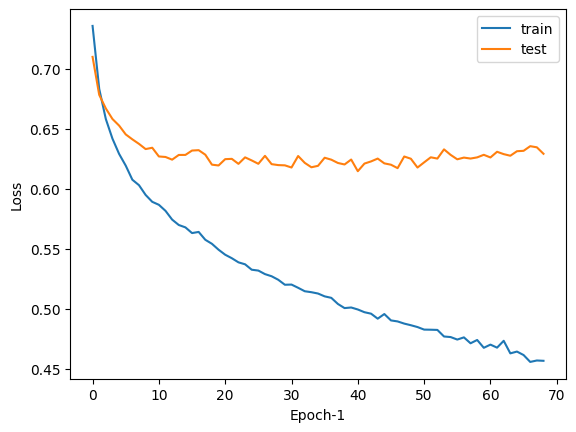

In [ ]:
# Prepare and plot loss over time
plt.plot(train_loss,label="train")
plt.plot(test_loss,label="test")
plt.legend()
plt.xlabel("Epoch-1")
plt.ylabel("Loss")
plt.show()

60/60 [==============================] - 0s 1ms/step
[4.822166  4.4608445 5.7931485 ... 5.4454503 5.99942   6.6958423]
Correlation coefficient: 0.6263670180524665


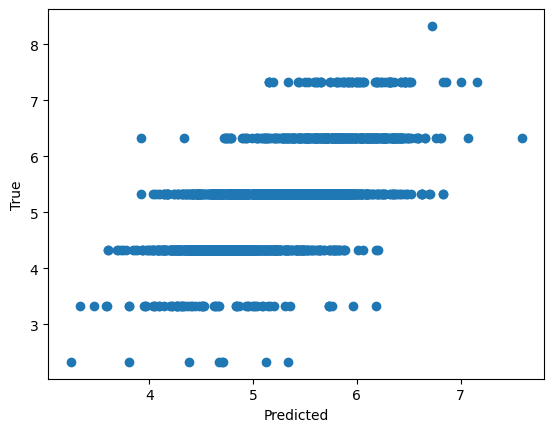

In [ ]:
# After the training:

# Prepare scatter plot
y_pred = model.predict(X_test)[:,0]


# now we need to rescale the output to the correct values
y_pred = (y_pred + mean[11])* std[11]
y_test = (y_test + mean[11])* std[11]
y_train = (y_train + mean[11]) * std[11]
print(y_pred)

print("Correlation coefficient:", np.corrcoef(y_pred,y_test)[0,1])
plt.scatter(y_pred,y_test)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()